# 04 2D Segmentation

This notebook introduces the segmentation stage of the pipeline, focusing on the RGB stream. We will evaluate the performance of SAM2 for segmenting and tracking the forklift and kettle across the video frames.
We start with the **SAM2** Segmentation model as a baseline and evaluate to **SAM3** only if it provides a meaningful improvement without excessive computational cost.


### In this notebook, we will:

1. **RGB stream sanity check**
   - Load the `.vrs` file with `projectaria_tools`.
   - Validate RGB stream access and timestamp consistency.

2. **Frames conversion to 10fps and prompt initialization**
   - Downsample the original 30fps frames to 10fps for efficient SAM2 inference.
   - Select only a few clean frames to initialize prompts.

3. **SAM2 baseline segmentation**
   - Multi-object prompting (forklift and kettle).
   - Mask propagation across time.

4. **Failure analysis and diagnostics**
   - Inspect drift, mask merging, holes, and missing thin parts.
   - Produce visual overlays for qualitative review.

5. **Targeted stress windows**
   - Evaluate difficult conditions: camera in/out motion, overlap, reflective kettle surfaces, and thin forklift structures.

6. **Quantitative temporal metrics**
   - Mask area stability, centroid jitter, temporal IoU, continuity/drop rate.


As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory.

For this notebook, we used as references:
* SAM2: https://github.com/facebookresearch/sam2
* SAM3: https://github.com/facebookresearch/sam3


## 4.1 RGB Stream Sanity Check

In this section we will perform a sanity check on the RGB stream by defining input/output paths and reading one RGB frame to validate decoding and timestamps.

We will create a grid of RGB frames sampled every 10 seconds to visually inspect the video content and confirm that we can access the frames correctly.

We will use some helper functions defined in `scripts/aria_dataset.py`

In [5]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from projectaria_tools.core import data_provider

# depends on installed projectaria_tools build
try:
    from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions
except Exception:
    TimeDomain = None
    TimeQueryOptions = None

In [6]:
# setup paths and validate VRS access
VRS_PATH = os.path.join("..", "data", "raw", "kettle_and_forklift", "kettle_and_forklift_recording.vrs")

OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", "kettle_and_forklift")
Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

if not os.path.exists(VRS_PATH):
    raise FileNotFoundError(f"VRS file not found: {os.path.abspath(VRS_PATH)}")

print("VRS path:", os.path.abspath(VRS_PATH))
print("Output root:", os.path.abspath(OUT_ROOT))


VRS path: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\kettle_and_forklift\kettle_and_forklift_recording.vrs
Output root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\kettle_and_forklift


In [7]:
# Helper functions for VRS access and RGB frame retrieval

from projectaria_tools.core import sensor_data
import sys
from pathlib import Path

# Add project root to sys.path
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]

project_root = next(
    (p for p in candidates if (p / "scripts" / "aria_dataset.py").exists()),
    None
)
if project_root is None:
    raise RuntimeError(f"Cannot find scripts/aria_dataset.py from cwd={cwd}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from scripts.aria_dataset import _extract_image_array_from_sample


def create_provider(vrs_path: str):
    """Create a VRS data provider for the given path."""
    provider = data_provider.create_vrs_data_provider(vrs_path)
    if provider is None:
        raise RuntimeError("Failed to create VRS data provider.")
    return provider


def resolve_rgb_stream(provider, rgb_stream_id_str: str = "214-1"):
    """Enumerate all streams and find the one matching the RGB stream id string."""
    rgb_candidates = [sid for sid in provider.get_all_streams() if str(sid) == rgb_stream_id_str]
    if len(rgb_candidates) == 0:
        raise RuntimeError(f"RGB stream {rgb_stream_id_str} not found in VRS.")
    rgb_stream_id = rgb_candidates[0]
    rgb_label = provider.get_label_from_stream_id(rgb_stream_id)
    rgb_sample_count = provider.get_num_data(rgb_stream_id)
    return rgb_label, rgb_stream_id, rgb_sample_count


def get_rgb_timestamps_ns(provider, stream_id, sample_count):
    """Get an array of timestamps in nanoseconds for all samples in the RGB stream."""
    ts = np.empty(sample_count, dtype=np.int64)
    for i in range(sample_count):
        s = provider.get_sensor_data_by_index(stream_id, i)
        ts[i] = s.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)
    return ts


def get_rgb_frame_by_index(provider, stream_id, index: int):
    """Get the RGB frame as a numpy array for the sample at the given index in the RGB stream."""
    sample = provider.get_sensor_data_by_index(stream_id, int(index))
    return _extract_image_array_from_sample(sample)

RGB stream label: camera-rgb
RGB stream id: 214-1
RGB sample count: 1551


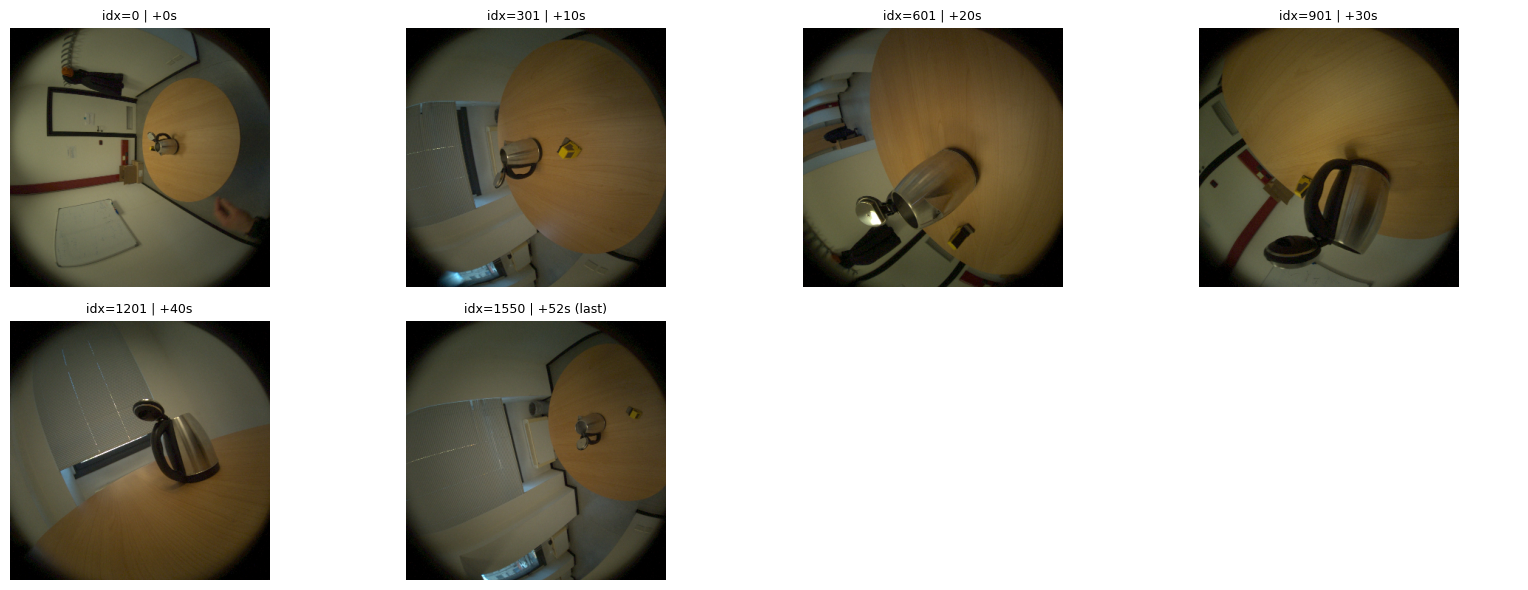

In [8]:
# as a sanity check we will create a grid with a frame every 10s

provider = create_provider(VRS_PATH)

rgb_label, rgb_stream_id, rgb_sample_count = resolve_rgb_stream(
    provider, rgb_stream_id_str="214-1"
)
rgb_timestamps_ns = get_rgb_timestamps_ns(provider, rgb_stream_id, rgb_sample_count)

print("RGB stream label:", rgb_label)
print("RGB stream id:", rgb_stream_id)
print("RGB sample count:", rgb_sample_count)

base_ts_ns = int(rgb_timestamps_ns[0])
last_ts_ns = int(rgb_timestamps_ns[-1])
duration_s = int((last_ts_ns - base_ts_ns) // 1_000_000_000)

step_s = 10
target_offsets_s = list(range(0, duration_s + 1, step_s))

# Get closest sample indices for target offsets
sample_indices = []
for off_s in target_offsets_s:
    target_ts_ns = base_ts_ns + off_s * 1_000_000_000
    idx = int(np.searchsorted(rgb_timestamps_ns, target_ts_ns, side="left"))
    if idx >= rgb_sample_count:
        idx = rgb_sample_count - 1
    sample_indices.append(idx)

# Force the last frame if it is not already included
if sample_indices[-1] != (rgb_sample_count - 1):
    sample_indices[-1] = rgb_sample_count - 1

# Remove duplicates while preserving order
seen = set()
sample_indices = [i for i in sample_indices if not (i in seen or seen.add(i))]

# Grid settings
downsample = 4  # 1=no resize, 2=1/2, 4=1/4
ncols = 4
nrows = (len(sample_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

# Display selected frames
for k in range(nrows * ncols):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    ax.axis("off")

    if k >= len(sample_indices):
        continue

    idx = sample_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = int(round((int(rgb_timestamps_ns[idx]) - base_ts_ns) / 1e9))
    is_last = (idx == rgb_sample_count - 1)

    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s}s{' (last)' if is_last else ''}", fontsize=9)

plt.tight_layout()
plt.show()

## 4.2 Frames conversion to 10fps and prompt initialization

In this section, we will convert the original 30fps frames to 10fps for efficient SAM2 inference. We will also select a few clean frames to initialize prompts for the segmentation model.

In [9]:
# Select evenly spaced candidate frames for prompt initialization

# Number of candidate frames to inspect
n_candidates = 8 # arbitrary choice

# Avoid first and last frame for initialization
start_idx = max(0, int(0.05 * rgb_sample_count))
end_idx = min(rgb_sample_count - 1, int(0.95 * rgb_sample_count))

candidate_indices = np.linspace(start_idx, end_idx, n_candidates, dtype=int).tolist()
candidate_indices = list(dict.fromkeys(candidate_indices))  # keep unique, preserve order

print("Candidate indices:", candidate_indices)

Candidate indices: [77, 276, 475, 675, 874, 1074, 1273, 1473]


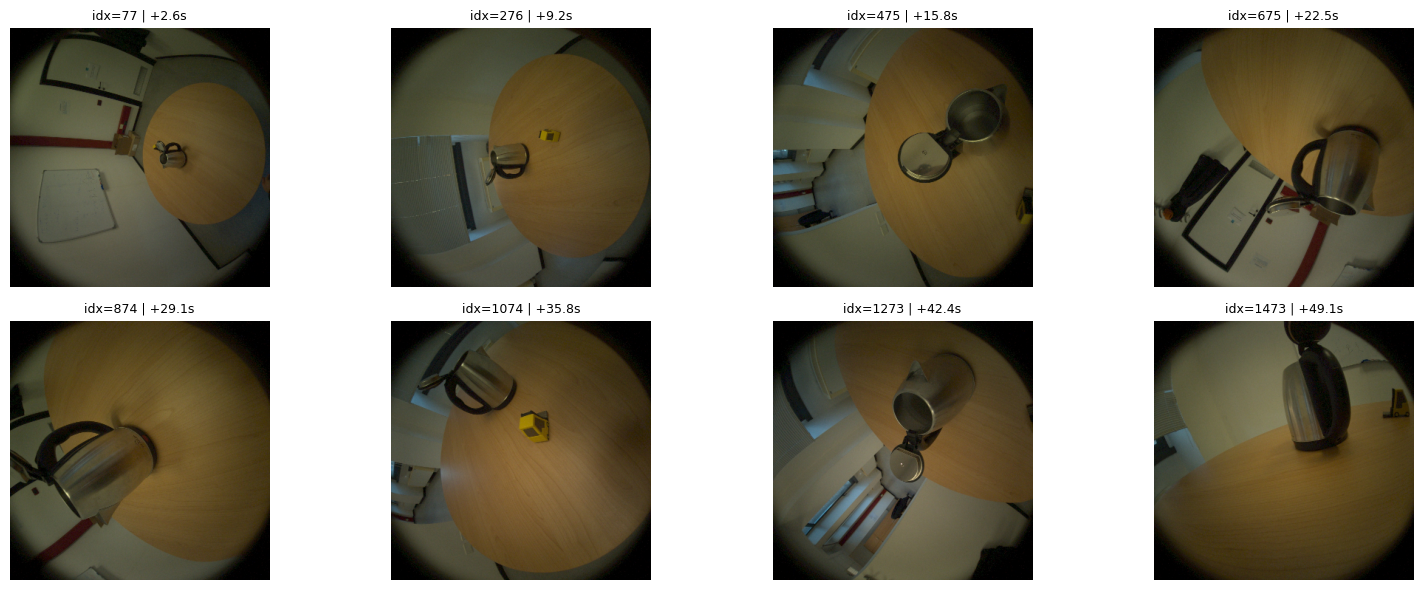

In [10]:
# Visualize candidate frames

downsample = 4
ncols = 4
nrows = (len(candidate_indices) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k in range(nrows * ncols):
    ax = axes.flat[k]
    ax.axis("off")
    if k >= len(candidate_indices):
        continue

    idx = candidate_indices[k]
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    frame_small = frame_rgb[::downsample, ::downsample]

    rel_s = (int(rgb_timestamps_ns[idx]) - int(rgb_timestamps_ns[0])) / 1e9
    ax.imshow(frame_small)
    ax.set_title(f"idx={idx} | +{rel_s:.1f}s", fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Manual prompt initialization frames selected after visual inspection
PROMPT_INIT_INDICES = [201, 373, 911, 1131]
PROMPT_FRAME_IDX = PROMPT_INIT_INDICES[0] # frame 201 is the best

print("Selected PROMPT_INIT_INDICES:", PROMPT_INIT_INDICES)
print("PROMPT_FRAME_IDX:", PROMPT_FRAME_IDX)

Selected PROMPT_INIT_INDICES: [201, 373, 911, 1131]
PROMPT_FRAME_IDX: 201


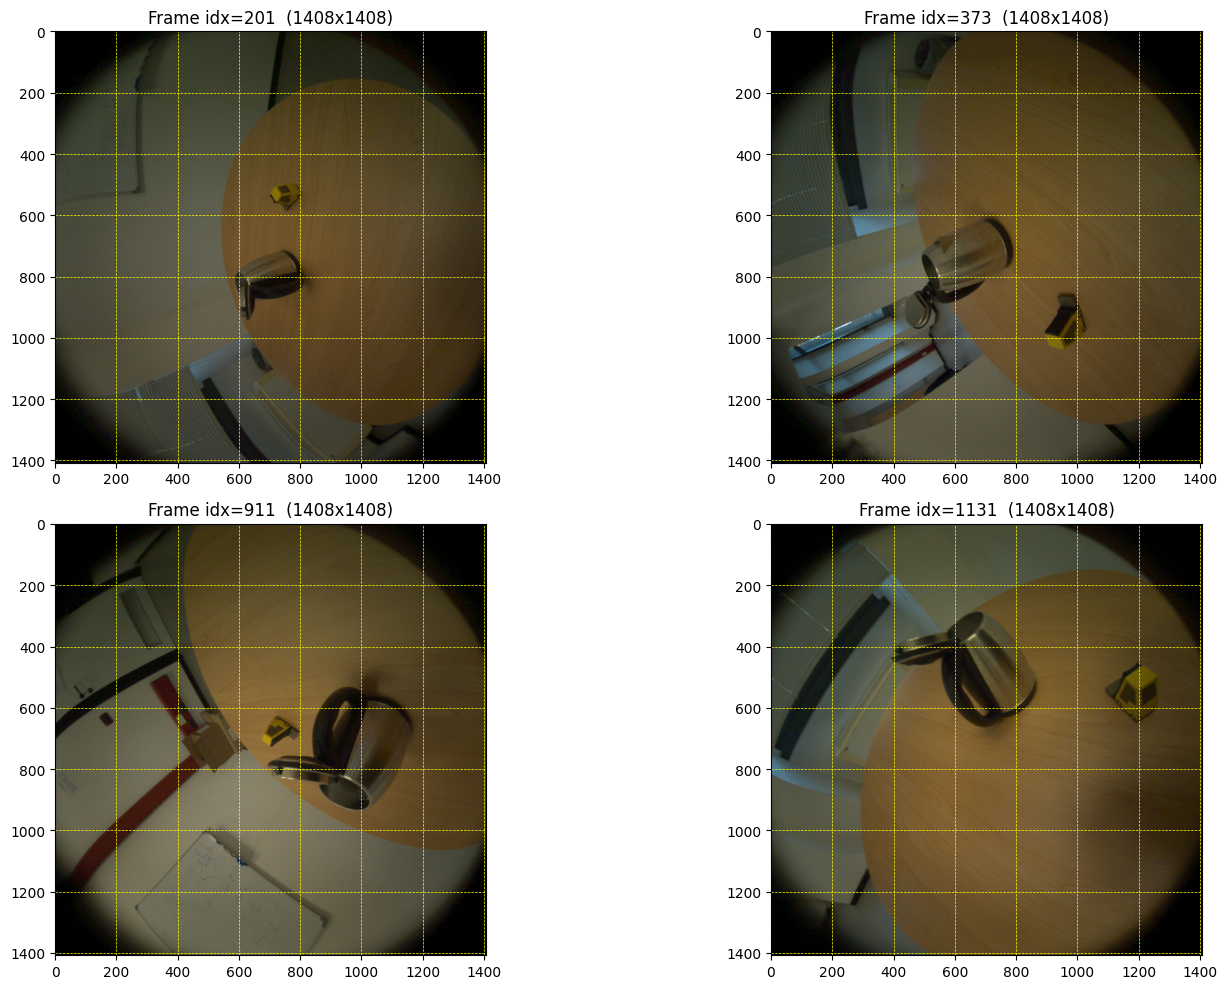

In [12]:
# Visualize the 4 selected prompt frames
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, idx in zip(axes, PROMPT_INIT_INDICES):
    frame_rgb = get_rgb_frame_by_index(provider, rgb_stream_id, idx)
    h, w = frame_rgb.shape[:2]
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame idx={idx}  ({w}x{h})")
    ax.axis("on")
    ax.set_xticks(np.arange(0, w + 1, 200))
    ax.set_yticks(np.arange(0, h + 1, 200))
    ax.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

### Candidate Frame Selection Criteria

Candidate frames are **not** selected randomly.

The selection follows a deterministic rule:

1. Define a central window of the RGB stream:
   - `start_idx = 5%` of the total RGB frame count
   - `end_idx = 95%` of the total RGB frame count  
   This avoids very early and very late frames, which are often less stable for prompt initialization.

2. Select `n_candidates` **evenly spaced** indices between `start_idx` and `end_idx` using:
   - `np.linspace(start_idx, end_idx, n_candidates, dtype=int)`

3. Remove potential duplicates while preserving order:
   - useful when the sequence is short or when `n_candidates` is high.

As a result, for the same video and parameters (`n_candidates`, 5%-95% range), the selected candidate frames are always the same.

## 4.3 SAM2 Baseline Segmentation

In this section we will use the SAM2 model to perform segmentation on the RGB frames using box prompts for the forklift and kettle.

The workflow is:

1. Export the RGB video frames to a folder that SAM2 can read.
2. Convert the original 30fps frames to 10fps.
3. Load the SAM2 video predictor.
4. Define object prompts for the target classes:
   - forklift
   - kettle
5. Initialize the masks on one clean frame.
6. Propagate the masks across the full video.

For the baseline, we use **box prompts** because they are stable, simple to inspect, and appropriate for the first segmentation pass.

In [13]:
from PIL import Image
import json
from collections import defaultdict

# SAM2 uses GPU when available
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [14]:
# Output folders
SAM2_ROOT = Path(OUT_ROOT) / "sam2"
SAM2_FRAMES_DIR = SAM2_ROOT / "frames"
SAM2_MASKS_DIR = SAM2_ROOT / "masks"
SAM2_VIS_DIR = SAM2_ROOT / "visualizations"

SAM2_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
SAM2_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_VIS_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
from pathlib import Path

# Validate SAM2 config and checkpoint paths
SAM2_CONFIG_FILE = Path("..") / "third_party" / "sam2" / "sam2" / "configs" / "sam2" / "sam2_hiera_s.yaml"
SAM2_CHECKPOINT = Path("..") / "checkpoints" / "sam2_hiera_small.pt"

if not SAM2_CONFIG_FILE.exists():
    raise FileNotFoundError(f"SAM2 config non trovato: {SAM2_CONFIG_FILE.resolve()}")
if not SAM2_CHECKPOINT.exists():
    raise FileNotFoundError(f"SAM2 checkpoint non trovato: {SAM2_CHECKPOINT.resolve()}")

print("SAM2_CONFIG_FILE:", SAM2_CONFIG_FILE.resolve())
print("SAM2_CHECKPOINT:", SAM2_CHECKPOINT.resolve())

SAM2_CONFIG_FILE: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\configs\sam2\sam2_hiera_s.yaml
SAM2_CHECKPOINT: C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\checkpoints\sam2_hiera_small.pt


In [16]:
from sam2.build_sam import build_sam2_video_predictor

#! Hydra wants a config-name, not an absolute path
SAM2_CONFIG_NAME = "configs/sam2/sam2_hiera_s.yaml"

# 4.3.2 Initialize SAM2 predictor
sam2_predictor = build_sam2_video_predictor(
    config_file=SAM2_CONFIG_NAME,
    ckpt_path=str(SAM2_CHECKPOINT),
    device=DEVICE,
)

print("Loaded SAM2 predictor.")

Loaded SAM2 predictor.


In [17]:
# 4.3.1 Function to export RGB frames as images for SAM2 processing
def export_rgb_frames(
    provider,
    stream_id,
    sample_count: int,
    out_dir: Path,
    ext: str = "jpg",
    jpg_quality: int = 95,
    force_rebuild: bool = False,
):
    """
    Export RGB frames as jpg images:
    000000.jpg, 000001.jpg, etc...
    If cache is complete and force_rebuild=False, skip export.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    # Check cache completeness
    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(sample_count)]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"Frame cache already complete. Skipping export: {out_dir}")
        return

    # If force_rebuild, clear existing files
    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    # Export frames
    for i in range(sample_count):
        out_path = out_dir / f"{i:06d}.jpg"
        if out_path.exists() and not force_rebuild:
            continue

        frame_rgb = get_rgb_frame_by_index(provider, stream_id, i)
        img = Image.fromarray(frame_rgb)
        img.save(out_path, quality=jpg_quality, subsampling=0, optimize=True)

    print(f"Export completed: {out_dir} ({sample_count} frames, .jpg)")


export_rgb_frames(
    provider=provider,
    stream_id=rgb_stream_id,
    sample_count=rgb_sample_count,
    out_dir=SAM2_FRAMES_DIR,
    ext="jpg",
    jpg_quality=95,
    force_rebuild=False,
)

Frame cache already complete. Skipping export: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames


### 4.3.3 Prompt index mapping from 30fps to 10fps

Before creating prompt boxes, convert the prompt frame index from the original 30fps timeline to the 10fps timeline used by SAM2 inference.
We map from the original frame to the corresponding frame in the 10fps to efficiently utilize computational resources.

In [18]:
# convert 30fps frames to 10fps by selecting every 3rd frame
import shutil

SAM2_FRAMES_DIR_10FPS = SAM2_ROOT / "frames_10fps"

def convert_frames_to_10fps(
    frames_dir: Path,
    out_dir: Path,
    original_fps: int = 30,
    target_fps: int = 10,
    ext: str = "jpg",
    force_rebuild: bool = False,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    ext = ext.lower().lstrip(".")

    frame_files = sorted(frames_dir.glob(f"*.{ext}"))
    if len(frame_files) == 0:
        raise RuntimeError(f"No frames found in {frames_dir} with extension .{ext}")

    step = int(round(original_fps / target_fps))
    if step <= 0:
        raise ValueError("Invalid fps ratio")

    selected_files = frame_files[::step]

    expected_files = [out_dir / f"{i:06d}.{ext}" for i in range(len(selected_files))]
    cache_complete = all(p.exists() for p in expected_files)

    if cache_complete and not force_rebuild:
        print(f"10fps cache already complete. Skipping conversion: {out_dir}")
        print(f"Frames already available: {len(selected_files)}")
        return

    if force_rebuild:
        for p in out_dir.glob(f"*.{ext}"):
            p.unlink()

    for i, src_path in enumerate(selected_files):
        dst_path = out_dir / f"{i:06d}.{ext}"
        if dst_path.exists() and not force_rebuild:
            continue
        shutil.copy2(src_path, dst_path)

    print(f"Converted {len(frame_files)} -> {len(selected_files)} frames in {out_dir}")

convert_frames_to_10fps(
    frames_dir=SAM2_FRAMES_DIR,
    out_dir=SAM2_FRAMES_DIR_10FPS,
    original_fps=30,
    target_fps=10,
    ext="jpg",
    force_rebuild=False,
)

10fps cache already complete. Skipping conversion: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames_10fps
Frames already available: 517


In [19]:
# Map prompt index from 30fps timeline to 10fps timeline

# Map prompt index from 30fps timeline to 10fps timeline
PROMPT_FRAME_IDX_30FPS = int(PROMPT_FRAME_IDX)
PROMPT_FRAME_IDX_10FPS = PROMPT_FRAME_IDX_30FPS // 3
frame_files_10fps = sorted(SAM2_FRAMES_DIR_10FPS.glob("*.jpg"))
if len(frame_files_10fps) == 0:
    raise RuntimeError(f"No JPG frames found in: {SAM2_FRAMES_DIR_10FPS}")

PROMPT_FRAME_IDX_10FPS = int(min(PROMPT_FRAME_IDX_10FPS, len(frame_files_10fps) - 1))

print("Prompt idx (30fps):", PROMPT_FRAME_IDX_30FPS)
print("Mapped prompt idx (10fps):", PROMPT_FRAME_IDX_10FPS)
print("10fps total frames:", len(frame_files_10fps))

Prompt idx (30fps): 201
Mapped prompt idx (10fps): 67
10fps total frames: 517


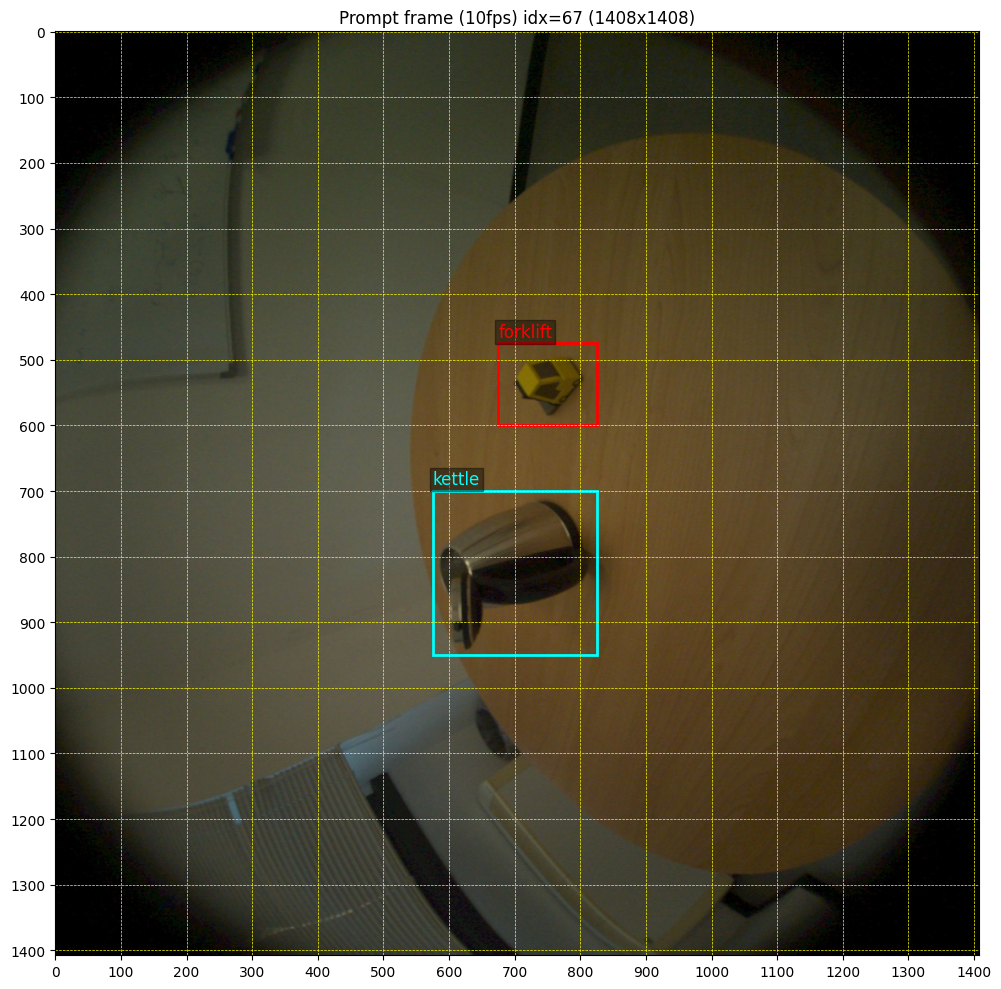

In [20]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# Load selected prompt frame from 10fps sequence
prompt_frame_10fps = np.array(Image.open(frame_files_10fps[PROMPT_FRAME_IDX_10FPS]).convert("RGB"))
h, w = prompt_frame_10fps.shape[:2]

# Define prompt boxes on the 10fps frame
BOX_PROMPTS_10FPS = {
    "forklift": [675, 475, 825, 600],
    "kettle": [575, 700, 825, 950],
}

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(prompt_frame_10fps)
ax.set_title(f"Prompt frame (10fps) idx={PROMPT_FRAME_IDX_10FPS} ({w}x{h})")
ax.axis("on")

ax.set_xticks(np.arange(0, w + 1, 100))
ax.set_yticks(np.arange(0, h + 1, 100))
ax.grid(color="yellow", linestyle="--", linewidth=0.5)

colors = {"forklift": "red", "kettle": "cyan"}
for name, box in BOX_PROMPTS_10FPS.items():
    x0, y0, x1, y1 = box
    rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor=colors[name], facecolor="none")
    ax.add_patch(rect)
    ax.text(
        x0,
        max(0, y0 - 10),
        name,
        color=colors[name],
        fontsize=12,
        bbox=dict(facecolor="black", alpha=0.4, pad=2),
    )

plt.tight_layout()
plt.show()

### 4.3.5 SAM2 inference

In this step we run SAM2 Small on the cropped RGB sequence.
The propagation is executed on GPU only, using the remapped box prompts on the selected prompt frame.
Outputs are saved as label masks, per-frame metadata, and visual overlays.

In [21]:
# Ensure no lingering references to SAM2 state or predictor that could hold GPU memory
for v in ["inference_state"]:
    if v in globals():
        del globals()[v]
import gc, torch
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [22]:
# clean up GPU memory before starting inference
import gc
import torch

# Clear Python references first
gc.collect()

if torch.cuda.is_available():
    # Wait for pending CUDA ops to finish
    torch.cuda.synchronize()

    # Release cached GPU memory held by PyTorch
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    # Optional: reset peak stats for cleaner monitoring
    torch.cuda.reset_peak_memory_stats()

    allocated_gb = torch.cuda.memory_allocated() / (1024**3)
    reserved_gb = torch.cuda.memory_reserved() / (1024**3)
    print(f"GPU memory after cleanup -> allocated: {allocated_gb:.3f} GB, reserved: {reserved_gb:.3f} GB")
else:
    print("CUDA not available.")

GPU memory after cleanup -> allocated: 0.308 GB, reserved: 0.320 GB


In [23]:
from PIL import Image
import time
import gc
import numpy as np
import torch

# This run requires a CUDA-capable GPU
if DEVICE != "cuda":
    raise RuntimeError("CUDA is required for this run.")

# 10fps frame folder
SAM2_FRAMES_DIR_10FPS = SAM2_ROOT / "frames_10fps"
if not SAM2_FRAMES_DIR_10FPS.exists():
    raise FileNotFoundError(f"Missing 10fps frames folder: {SAM2_FRAMES_DIR_10FPS}")

# Sorted list of 10fps frames
frame_files_10fps = sorted(SAM2_FRAMES_DIR_10FPS.glob("*.jpg"))
if len(frame_files_10fps) == 0:
    raise RuntimeError(f"No JPG frames found in: {SAM2_FRAMES_DIR_10FPS}")

# Output folders
SAM2_MASKS_DIR = SAM2_ROOT / "masks"
SAM2_VIS_DIR = SAM2_ROOT / "visualizations"
SAM2_MASKS_DIR.mkdir(parents=True, exist_ok=True)
SAM2_VIS_DIR.mkdir(parents=True, exist_ok=True)

# Runtime controls
SAVE_OVERLAYS = False
SAVE_EVERY_N = 1
CLEAN_PREVIOUS_OUTPUTS = False

# Optionally clear previous outputs before running
if CLEAN_PREVIOUS_OUTPUTS:
    for p in SAM2_MASKS_DIR.glob("*.png"):
        p.unlink()
    for p in SAM2_VIS_DIR.glob("*.jpg"):
        p.unlink()

# Map the prompt from the 30fps timeline to the 10fps timeline
prompt_frame_idx_10fps = int(min(PROMPT_FRAME_IDX_10FPS, len(frame_files_10fps) - 1))
ACTIVE_BOX_PROMPTS = BOX_PROMPTS_10FPS

# Object label mapping
OBJECT_IDS = {"forklift": 1, "kettle": 2}
VALID_IDS = set(OBJECT_IDS.values())

# Release any cached GPU memory before starting
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

# Initialize SAM2 on the 10fps sequence
inference_state = sam2_predictor.init_state(
    video_path=str(SAM2_FRAMES_DIR_10FPS),
    offload_video_to_cpu=False,
    offload_state_to_cpu=False,
)
sam2_predictor.reset_state(inference_state)

print("Initialized SAM2 state on:", SAM2_FRAMES_DIR_10FPS)
print("Frames available:", len(frame_files_10fps))
print("Prompt frame idx used:", prompt_frame_idx_10fps)
print("SAVE_OVERLAYS:", SAVE_OVERLAYS, "| SAVE_EVERY_N:", SAVE_EVERY_N, "| CLEAN_PREVIOUS_OUTPUTS:", CLEAN_PREVIOUS_OUTPUTS)

# Add box prompts on the selected prompt frame
for obj_name, box in ACTIVE_BOX_PROMPTS.items():
    obj_id = OBJECT_IDS[obj_name]
    _, out_obj_ids, out_mask_logits = sam2_predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=prompt_frame_idx_10fps,
        obj_id=int(obj_id),
        box=np.array(box, dtype=np.float32),
    )
    print(f"Added prompt: {obj_name} -> obj_id={obj_id}, box={box}")

def build_label_mask_fast(out_obj_ids, out_mask_logits):
    # Build a labeled mask where:
    # 0 = background
    # 1 = forklift
    # 2 = kettle
    h, w = out_mask_logits.shape[-2], out_mask_logits.shape[-1]
    label_mask = np.zeros((h, w), dtype=np.uint8)

    for i, obj_id in enumerate(out_obj_ids):
        obj_id = int(obj_id)
        if obj_id not in VALID_IDS:
            continue

        # Positive logits are treated as foreground pixels
        binary = (out_mask_logits[i, 0] > 0).detach().cpu().numpy()
        label_mask[binary] = obj_id

    return label_mask

def save_mask(frame_idx, out_obj_ids, out_mask_logits):
    # Save one mask immediately to disk
    label_mask = build_label_mask_fast(out_obj_ids, out_mask_logits)
    mask_path = SAM2_MASKS_DIR / f"{int(frame_idx):06d}.png"
    Image.fromarray(label_mask).save(mask_path, compress_level=1)
    return mask_path

all_results = {}
t0 = time.time()
processed = 0

with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
    # Backward pass: prompt -> first frame
    backward_count = 0
    for out_frame_idx, out_obj_ids, out_mask_logits in sam2_predictor.propagate_in_video(
        inference_state,
        start_frame_idx=prompt_frame_idx_10fps,
        max_frame_num_to_track=prompt_frame_idx_10fps + 1,
        reverse=True,
    ):
        idx = int(out_frame_idx)

        # Skip frames if subsampling is enabled
        if (idx % SAVE_EVERY_N) != 0:
            continue

        mask_path = save_mask(idx, out_obj_ids, out_mask_logits)
        all_results[idx] = {
            "mask_path": str(mask_path),
            "vis_path": None,
        }

        processed += 1
        if processed % 50 == 0:
            dt = time.time() - t0
            print(f"Processed {processed} frames in {dt:.1f}s ({processed / max(dt, 1e-6):.2f} fps)")

        backward_count += 1

    # Forward pass: prompt -> last frame
    forward_count = 0
    forward_len = len(frame_files_10fps) - prompt_frame_idx_10fps

    for out_frame_idx, out_obj_ids, out_mask_logits in sam2_predictor.propagate_in_video(
        inference_state,
        start_frame_idx=prompt_frame_idx_10fps,
        max_frame_num_to_track=forward_len,
        reverse=False,
    ):
        idx = int(out_frame_idx)

        if (idx % SAVE_EVERY_N) != 0:
            continue

        mask_path = save_mask(idx, out_obj_ids, out_mask_logits)
        all_results[idx] = {
            "mask_path": str(mask_path),
            "vis_path": None,
        }
        
        forward_count += 1

print("Backward frames iterated:", backward_count)
print("Forward frames iterated:", forward_count)
print("Saved frames:", len(all_results))
print("First saved idx:", min(all_results) if all_results else None)
print("Last saved idx:", max(all_results) if all_results else None)

frame loading (JPEG): 100%|██████████| 517/517 [00:32<00:00, 16.07it/s]


Initialized SAM2 state on: ..\data\outputs\segmentation\kettle_and_forklift\sam2\frames_10fps
Frames available: 517
Prompt frame idx used: 67
SAVE_OVERLAYS: False | SAVE_EVERY_N: 1 | CLEAN_PREVIOUS_OUTPUTS: False


C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (C:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\third_party\sam2\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Added prompt: forklift -> obj_id=1, box=[675, 475, 825, 600]
Added prompt: kettle -> obj_id=2, box=[575, 700, 825, 950]


propagate in video:  74%|███████▎  | 50/68 [07:53<02:59,  9.96s/it]

...

Processed 450 frames in 4534.6s (0.10 fps)


propagate in video:  96%|█████████▌| 432/450 [1:13:15<03:04, 10.23s/it]

Processed 500 frames in 5052.7s (0.10 fps)


propagate in video: 100%|██████████| 450/450 [1:16:19<00:00, 10.18s/it]

Backward frames iterated: 68
Forward frames iterated: 450
Saved frames: 517
First saved idx: 0
Last saved idx: 516


## 4.4 Failure Analysis and Diagnostics

In this section we will compute frame-level diagnostics for SAM2 masks and identify critical frames where missing object events occur or sudden area changes appear

We will load all saved masks, compute area and centroid metrics for each object across time, and perform early failure triage.

In [24]:
# 4.4.1: Load masks and compute metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

MASK_DIR = Path(SAM2_MASKS_DIR)
VIS_DIR = Path(SAM2_VIS_DIR)
FRAME_DIR = Path(SAM2_FRAMES_DIR_10FPS)

# Validate directories
mask_files = sorted(MASK_DIR.glob("*.png"))
if len(mask_files) == 0:
    raise RuntimeError(f"No mask files found in {MASK_DIR}")

print(f"Found {len(mask_files)} mask files")
print("First:", mask_files[0].name, "| Last:", mask_files[-1].name)

# Robust z-score function for outlier detection
def robust_zscore(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if not np.isfinite(mad) or mad == 0:
        return np.zeros_like(x, dtype=float)
    return 0.6745 * (x - med) / mad

# Compute area and centroid for a binary mask
def area_and_centroid(binary_mask: np.ndarray):
    area = int(binary_mask.sum())
    if area == 0:
        return area, np.nan, np.nan
    ys, xs = np.where(binary_mask)
    return area, float(xs.mean()), float(ys.mean())

# Build a DataFrame with frame_idx, object, area, cx, cy for each mask
def build_metrics(mask_paths, object_ids: dict) -> pd.DataFrame:
    rows = []
    for p in mask_paths:
        frame_idx = int(p.stem)
        label_mask = np.array(Image.open(p), dtype=np.uint8)
        for obj_name, obj_id in object_ids.items():
            binary = label_mask == int(obj_id)
            area, cx, cy = area_and_centroid(binary)
            rows.append(
                {
                    "frame_idx": frame_idx,
                    "object": obj_name,
                    "area": area,
                    "cx": cx,
                    "cy": cy,
                }
            )
    return pd.DataFrame(rows).sort_values(["object", "frame_idx"]).reset_index(drop=True)

metrics_df = build_metrics(mask_files, OBJECT_IDS)
print(f"\nMetrics shape: {metrics_df.shape}")
print(metrics_df.head(10))

Found 517 mask files
First: 000000.png | Last: 000516.png

Metrics shape: (1034, 5)
   frame_idx    object  area          cx          cy
0          0  forklift    77  759.116883  655.792208
1          1  forklift    70  750.400000  646.042857
2          2  forklift    46  744.760870  636.413043
3          3  forklift    41  745.804878  635.121951
4          4  forklift    82  750.304878  638.219512
5          5  forklift    39  755.974359  645.128205
6          6  forklift    36  773.361111  651.916667
7          7  forklift    27  790.185185  657.666667
8          8  forklift    43  777.581395  654.906977
9          9  forklift    14  762.857143  661.071429


In [ ]:
# 4.4.2 Early Failure Triage

# Analyze the metrics to identify early failure patterns
def longest_true_run(mask: np.ndarray):
    best_len = 0
    best_start = -1
    cur_len = 0
    cur_start = -1
    for i, v in enumerate(mask):
        if v:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_len = cur_len
                best_start = cur_start
        else:
            cur_len = 0
            cur_start = -1
    if best_len == 0:
        return 0, -1, -1
    return best_len, best_start, best_start + best_len - 1

# Analyze missing object events (area=0) for each object and print summary statistics
for obj_name in sorted(metrics_df["object"].unique()):
    d = metrics_df[metrics_df["object"] == obj_name].sort_values("frame_idx").reset_index(drop=True)
    missing = (d["area"].to_numpy() == 0)
    
    miss_rate = float(missing.mean()) * 100.0
    first_missing = int(d.loc[missing, "frame_idx"].iloc[0]) if missing.any() else None
    run_len, run_s, run_e = longest_true_run(missing)
    
    print(f"\n{'='*60}")
    print(f"Object: {obj_name.upper()}")
    print(f"{'='*60}")
    print(f"Missing rate: {miss_rate:.2f}%")
    print(f"First missing frame: {first_missing}")
    if run_len > 0:
        print(f"Longest missing streak: {run_len} frames (frames {run_s} => {run_e})")
    else:
        print("Longest missing streak: 0")
    print(f"{'='*60}")


Object: FORKLIFT
Missing rate: 14.89%
First missing frame: 218
Longest missing streak: 55 frames (frames 398->452)

Object: KETTLE
Missing rate: 0.00%
First missing frame: None
Longest missing streak: 0
